
# Predictive Modeling for Bank Direct Marketing Campaigns

## About The Project

**This project focuses on optimizing the direct marketing operations (telemarketing phone calls) of a Portuguese banking institution. The core classification objective is to build a machine learning model capable of predicting whether a client will subscribe to a term deposit (variable `y`).**

**In the banking sector, telemarketing is a highly resource-intensive process. Calling every single client in a database is inefficient and drives up operational costs, while failing to contact genuinely interested clients results in direct revenue loss. To solve this, this project evaluates predictive models—specifically Gaussian Naive Bayes and Decision Tree Classifiers—to intelligently segment the client base.**

**To maximize both profitability and call center efficiency, our model evaluation is anchored to two specific business metrics:**
* **Maximizing Recall for Subscriptions (`y=1`):** Our primary goal for positive predictions is to capture as many actual subscribers as possible, ensuring the bank does not miss out on potential term deposit conversions. 
* **Maximizing Precision for Non-Subscriptions (`y=0`):** We require a highly reliable filter to identify clients who will *not* subscribe. High precision here guarantees that when the model recommends skipping a client, the bank can confidently do so without losing a sale, thereby saving telemarketers' time and drastically reducing campaign costs.

**The following sections detail the data analysis, model development, and comparative evaluation used to determine the most effective algorithmic strategy for this marketing campaign.**

# Data loading and description

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
bank_data = pd.read_csv("D:/Local Disk/Downloads/bank-additional-full.csv",sep=";")
bank_data.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
19769,33,technician,married,high.school,unknown,no,no,cellular,aug,fri,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
16444,26,admin.,single,high.school,no,no,yes,cellular,jul,wed,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no
36794,20,technician,single,unknown,no,no,no,cellular,jun,mon,...,1,999,0,nonexistent,-2.9,92.963,-40.8,1.260,5076.2,yes
35185,58,admin.,married,basic.4y,unknown,no,yes,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.250,5099.1,no
4938,56,admin.,married,university.degree,unknown,no,no,telephone,may,wed,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.858,5191.0,no


In [6]:
bank_data.shape

(41188, 21)

In [7]:
bank_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [8]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [9]:
bank_data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [10]:
bank_data[bank_data=="unknown"].count()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

# Data preprocessing

## Null values:

In [11]:
bank_data.isnull().sum() # No null values

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

## Duplicate Handling

In [12]:
bank_data.duplicated().sum()

np.int64(12)

In [13]:
bank_data.drop_duplicates(inplace=True)

# Exploratory Data Analysis

## univariate analysis

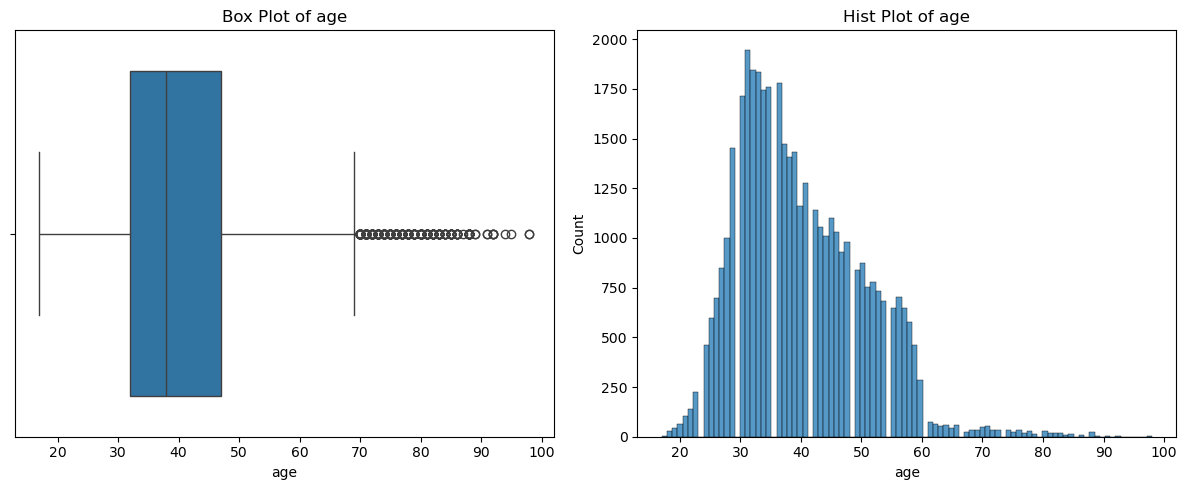

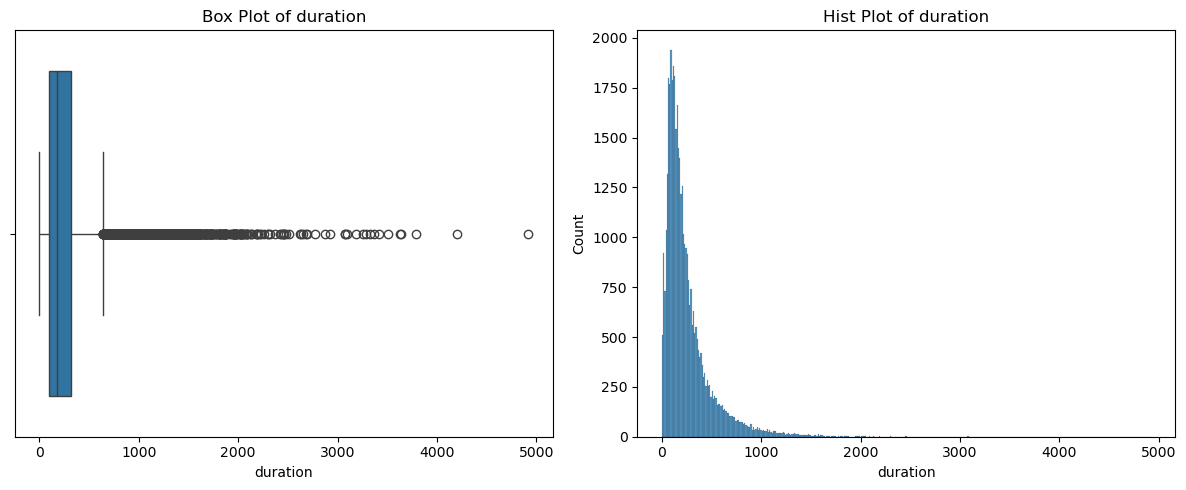

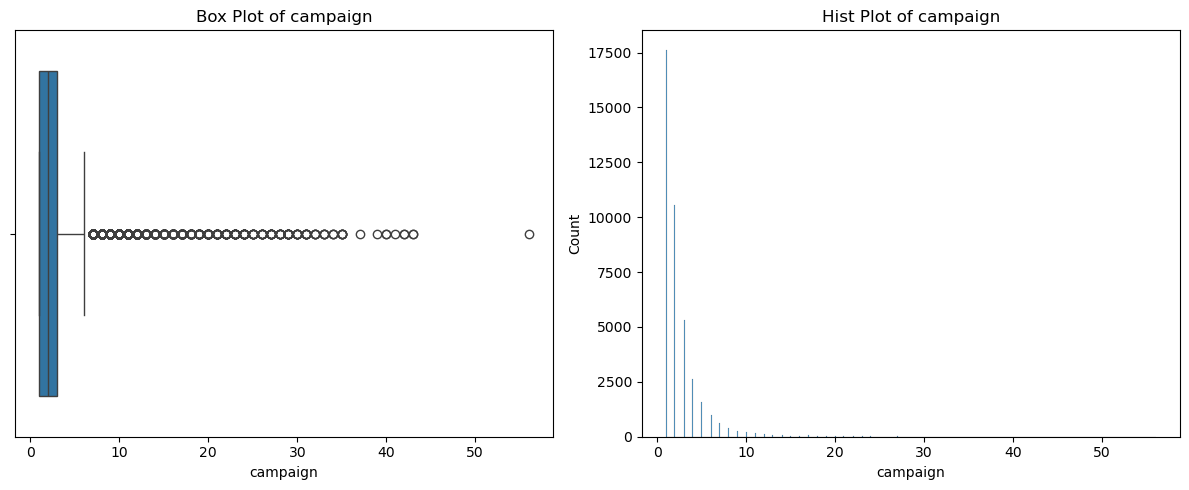

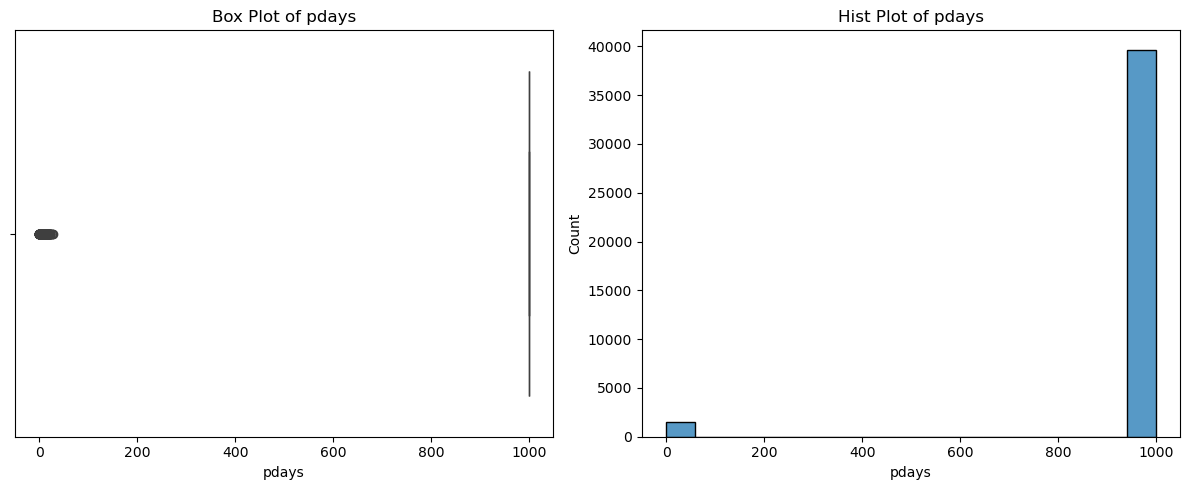

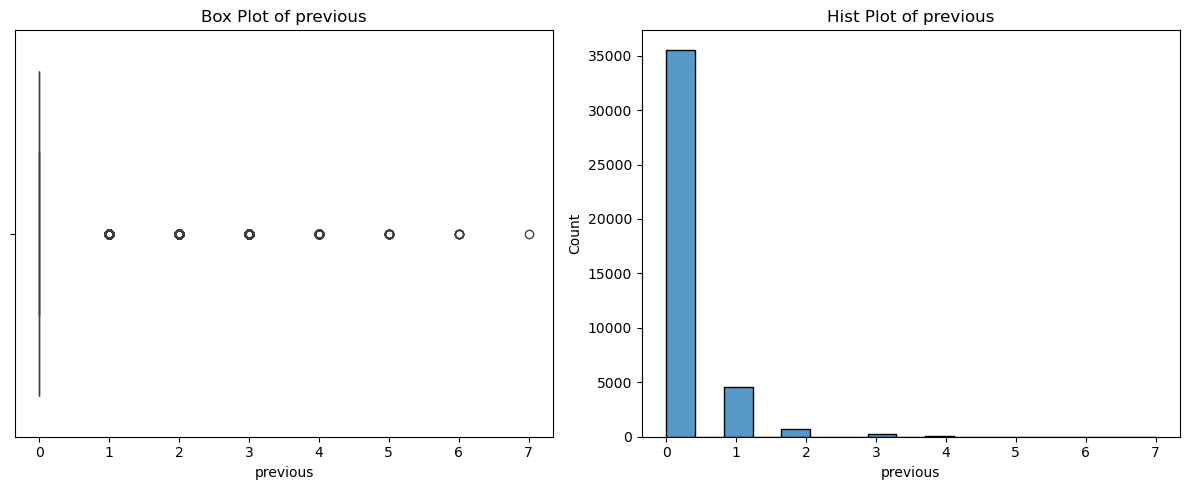

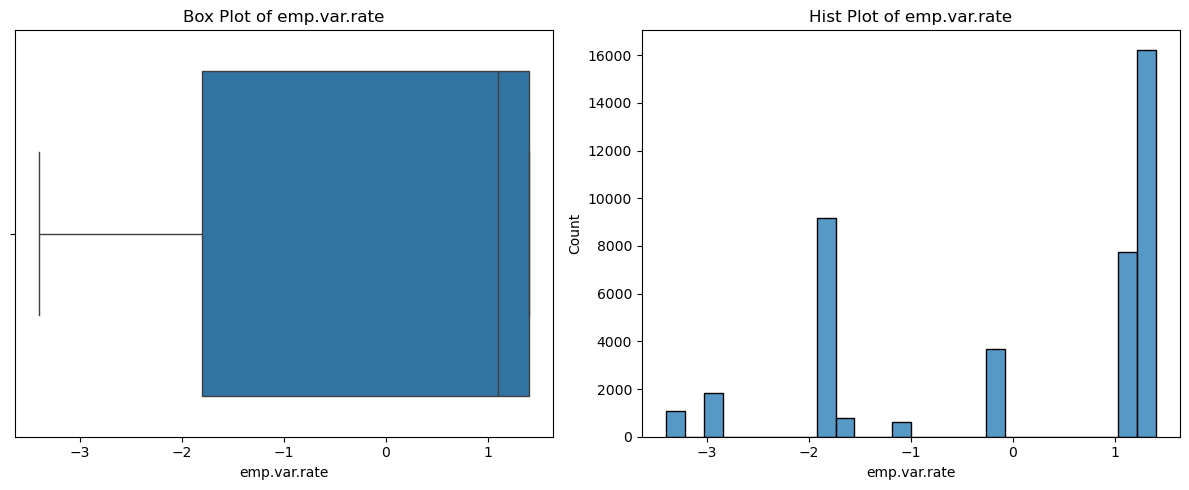

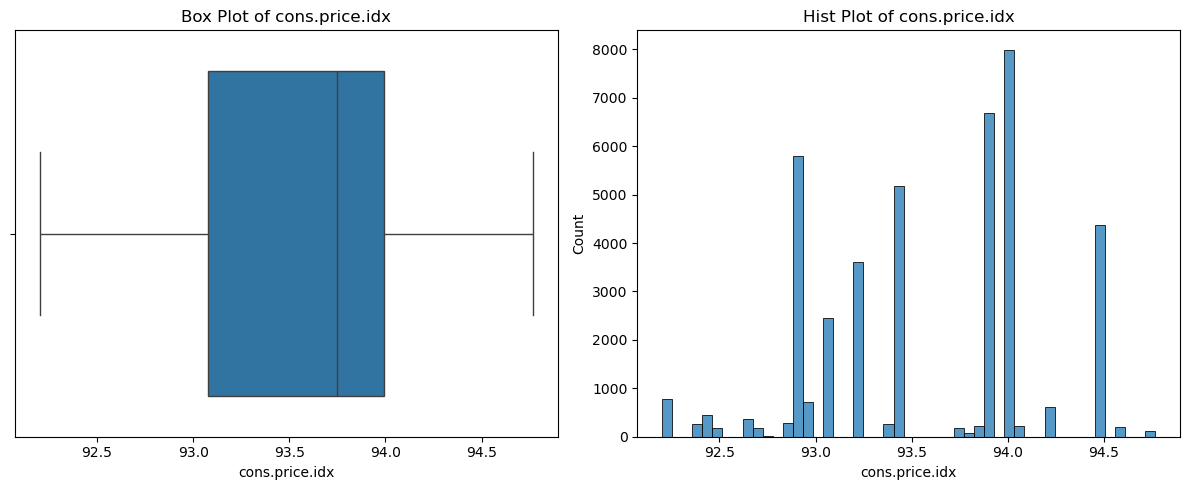

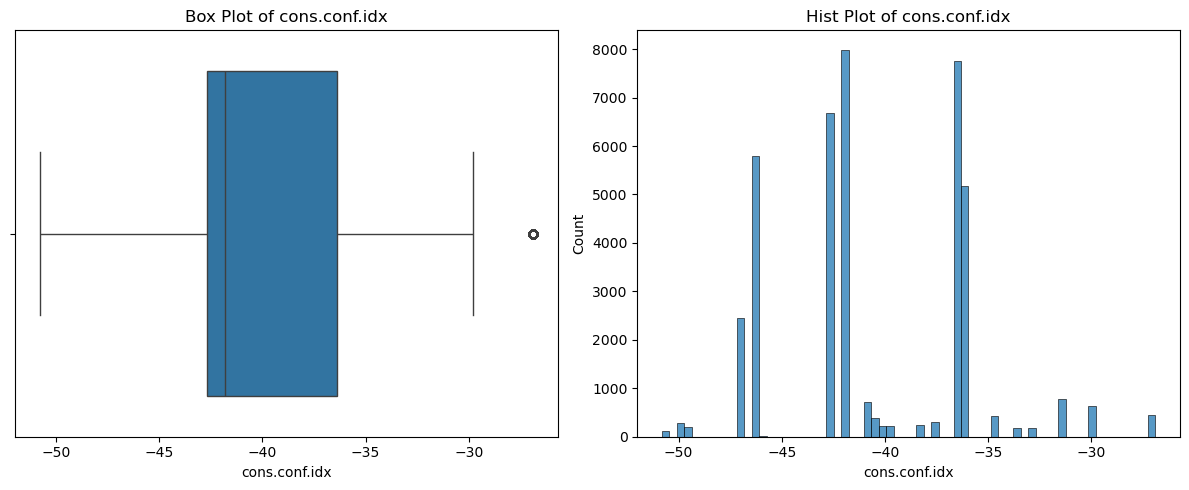

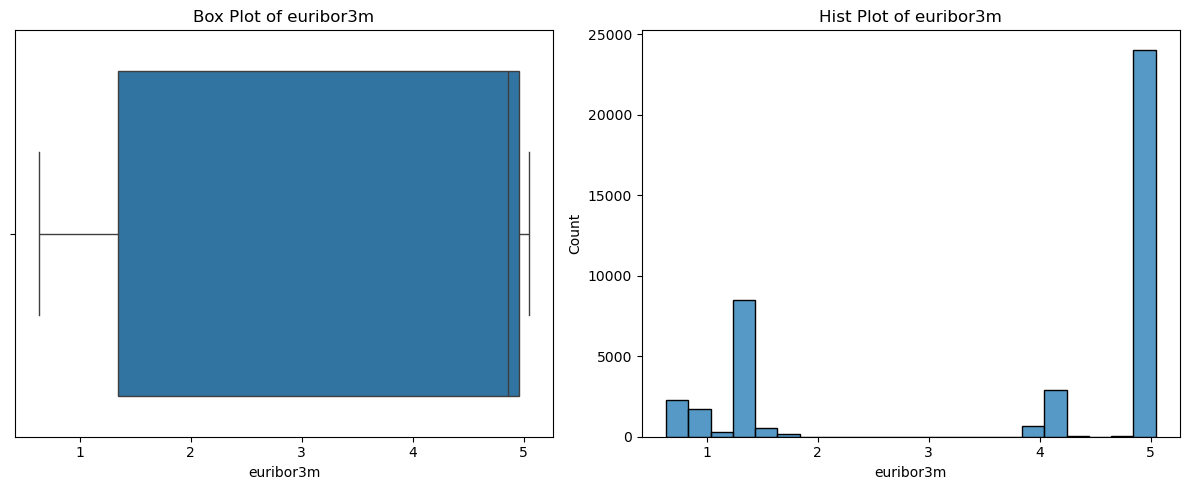

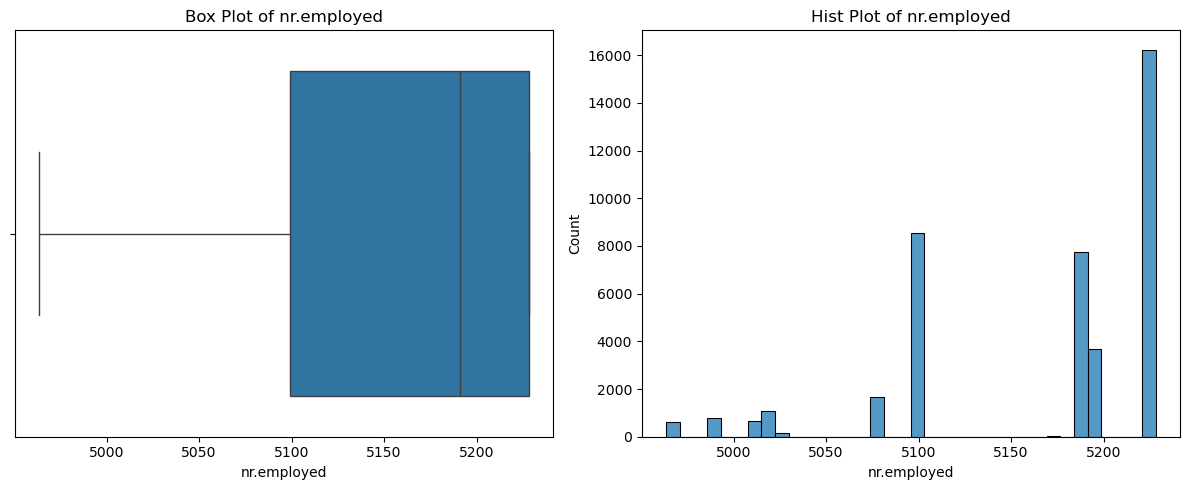

In [14]:
numcol=['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
for x in numcol:
    fig, ax = plt.subplots(nrows= 1,ncols= 2, figsize=(12,5))
    sns.boxplot(bank_data, x=x, ax= ax[0])
    ax[0].set_title(f"Box Plot of {x}")
    sns.histplot(bank_data, x=x, ax= ax[1])
    ax[1].set_title(f"Hist Plot of {x}")
    plt.tight_layout()
    plt.show()

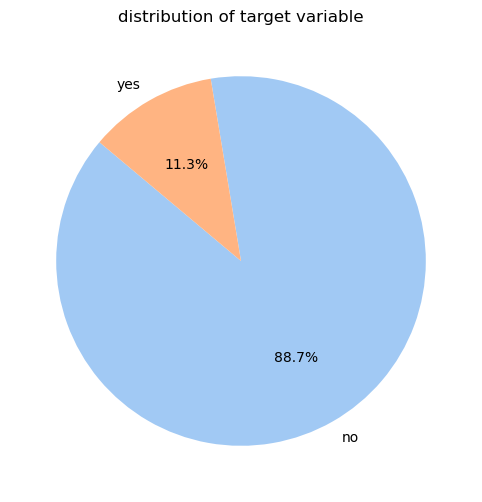

In [15]:
counts = bank_data["y"].value_counts()
plt.figure(figsize=(12,6))
plt.pie(counts, 
              labels=counts.index, 
              autopct='%1.1f%%', 
              startangle=140,    
              colors=sns.color_palette('pastel'))
plt.title("distribution of target variable")
plt.show()

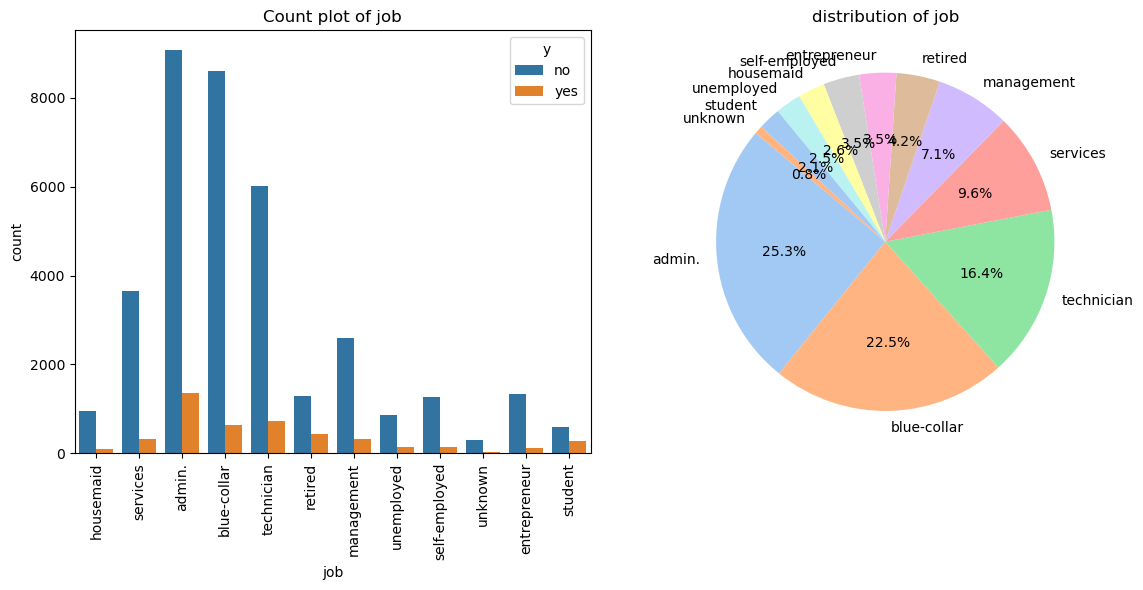

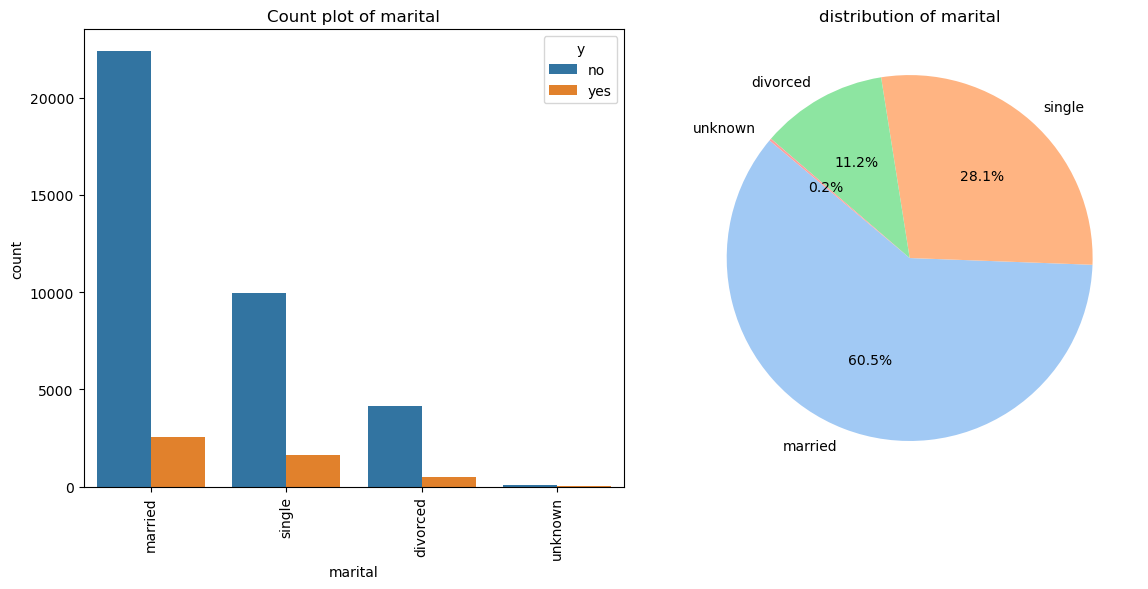

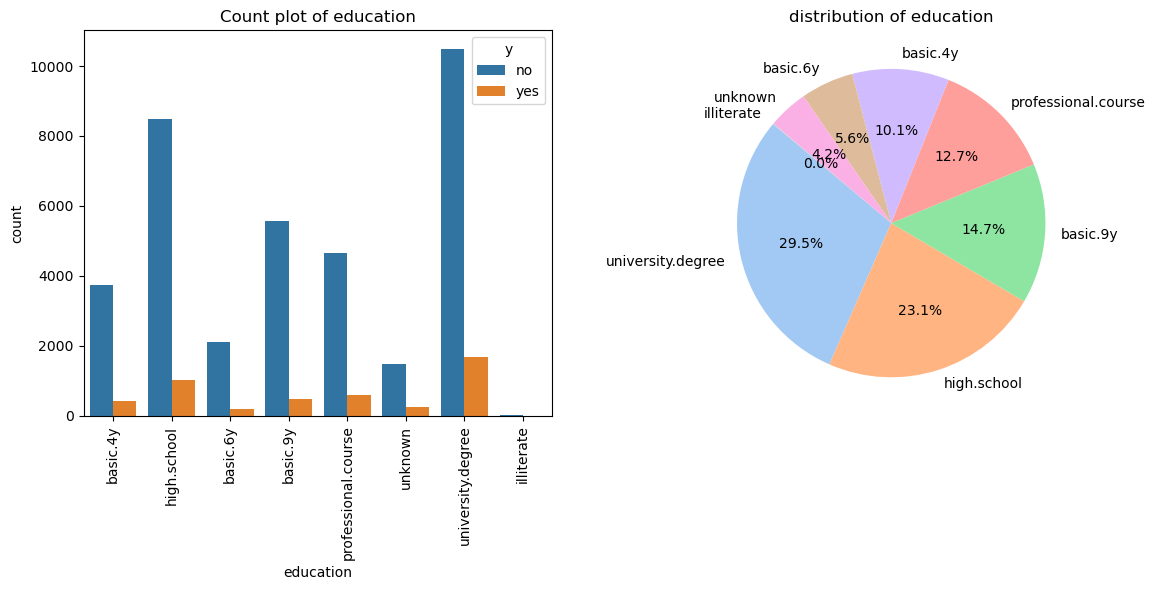

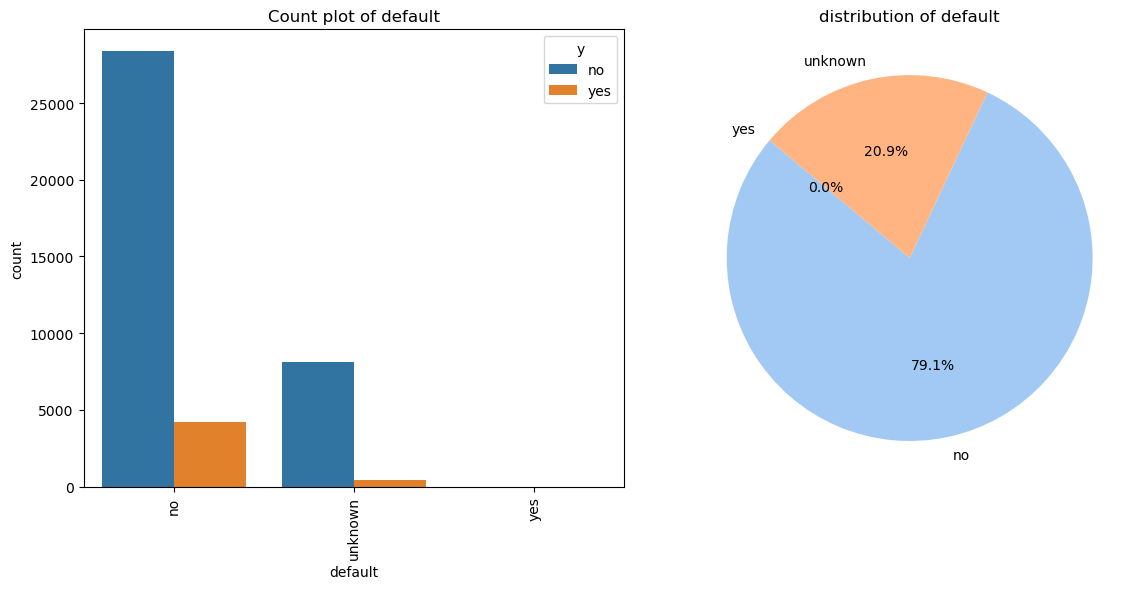

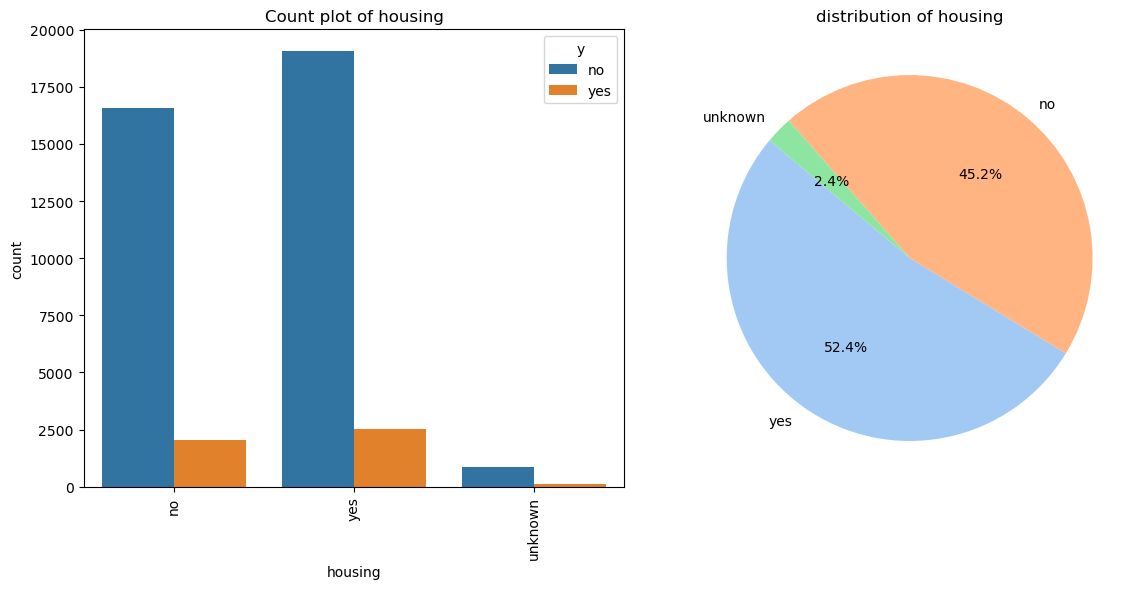

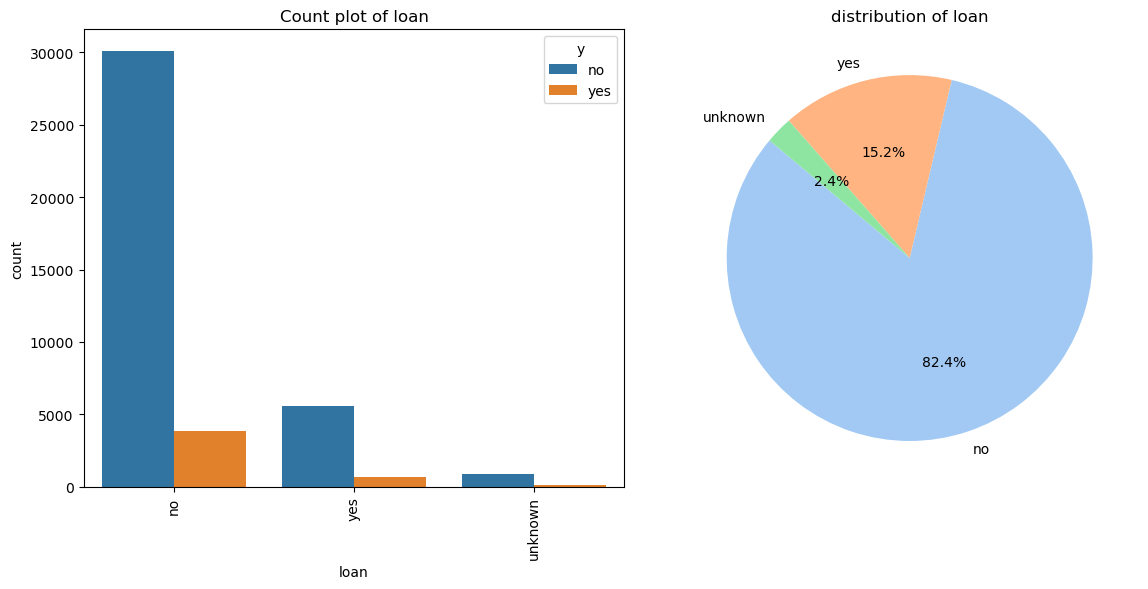

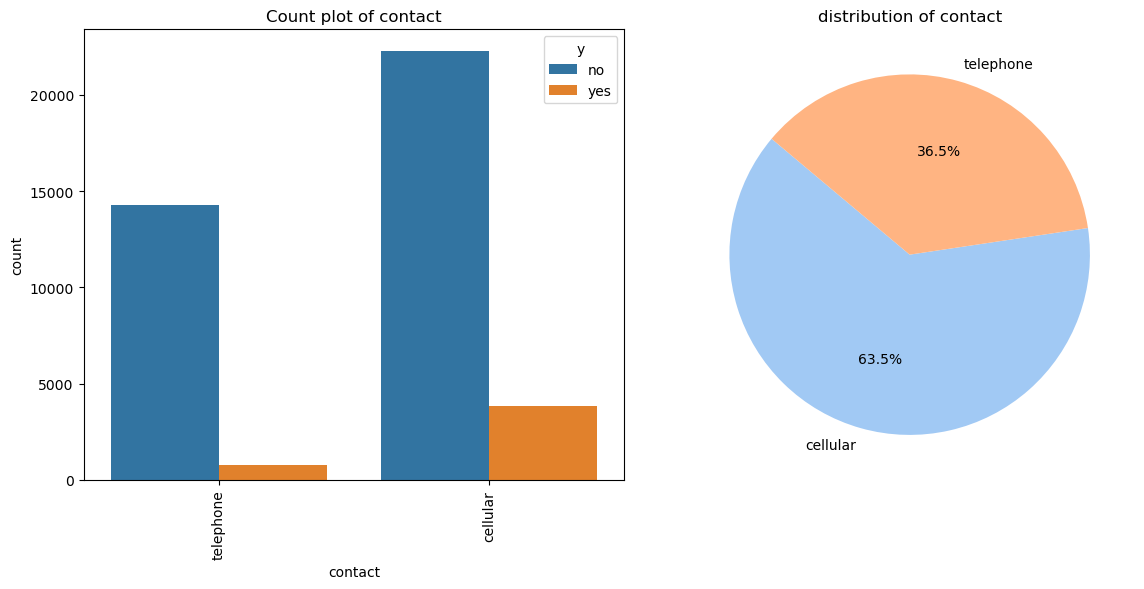

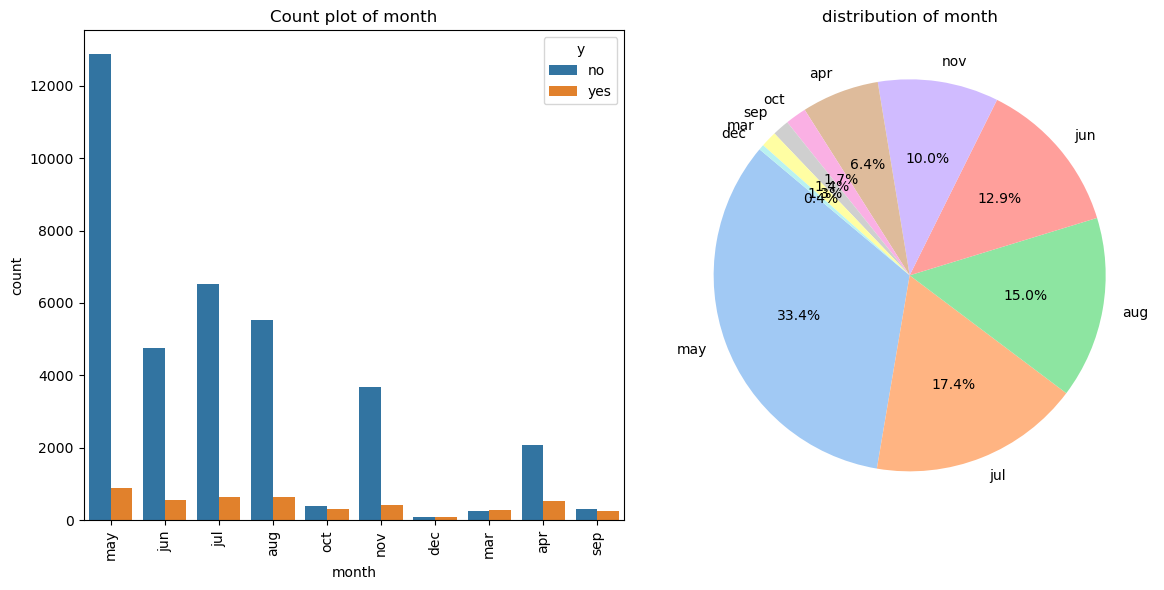

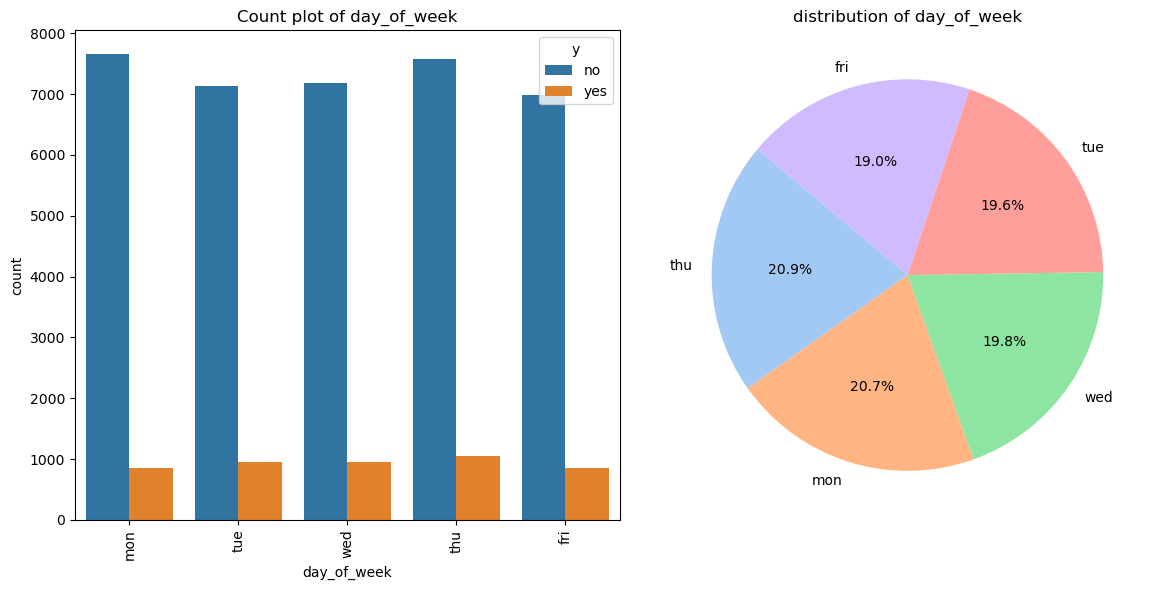

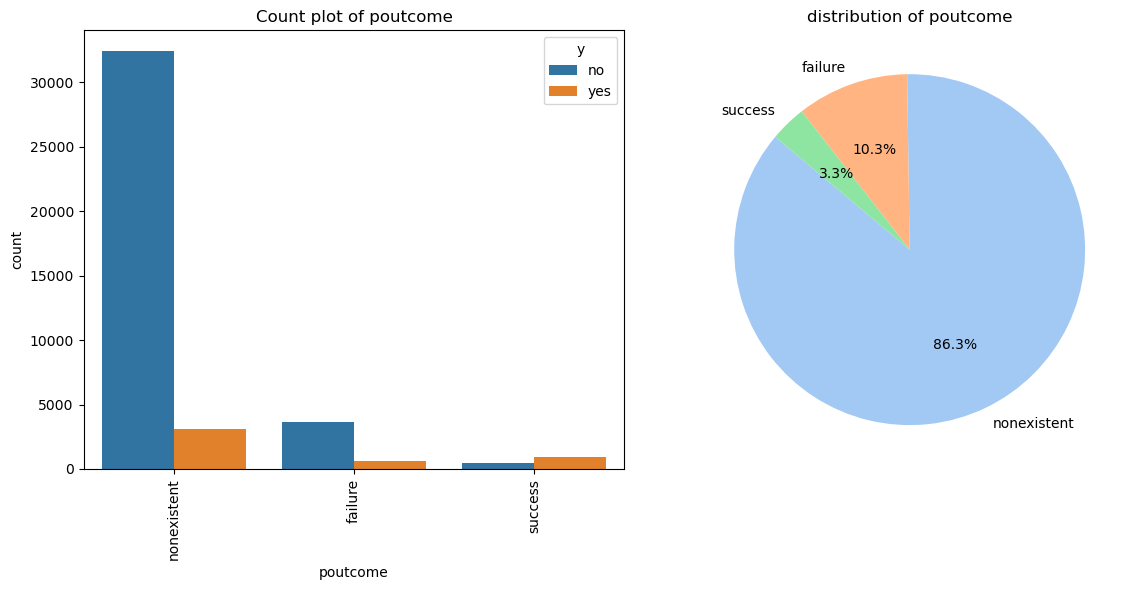

In [16]:
col_cat=['job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', "day_of_week",'poutcome']

for x in col_cat:
    fig, ax= plt.subplots(1,2,figsize=(12,6))
    sns.countplot(bank_data, x= x,hue= "y", ax= ax[0])
    ax[0].set_title(f"Count plot of {x}")
    counts = bank_data[x].value_counts()
    ax[1].pie(counts, 
              labels=counts.index, 
              autopct='%1.1f%%', 
              startangle=140,    
              colors=sns.color_palette('pastel'))
    ax[1].set_title(f"distribution of {x}")
    ax[0].tick_params(axis='x', labelrotation=90)
    plt.tight_layout()
    plt.show()
    

## correlation matrix

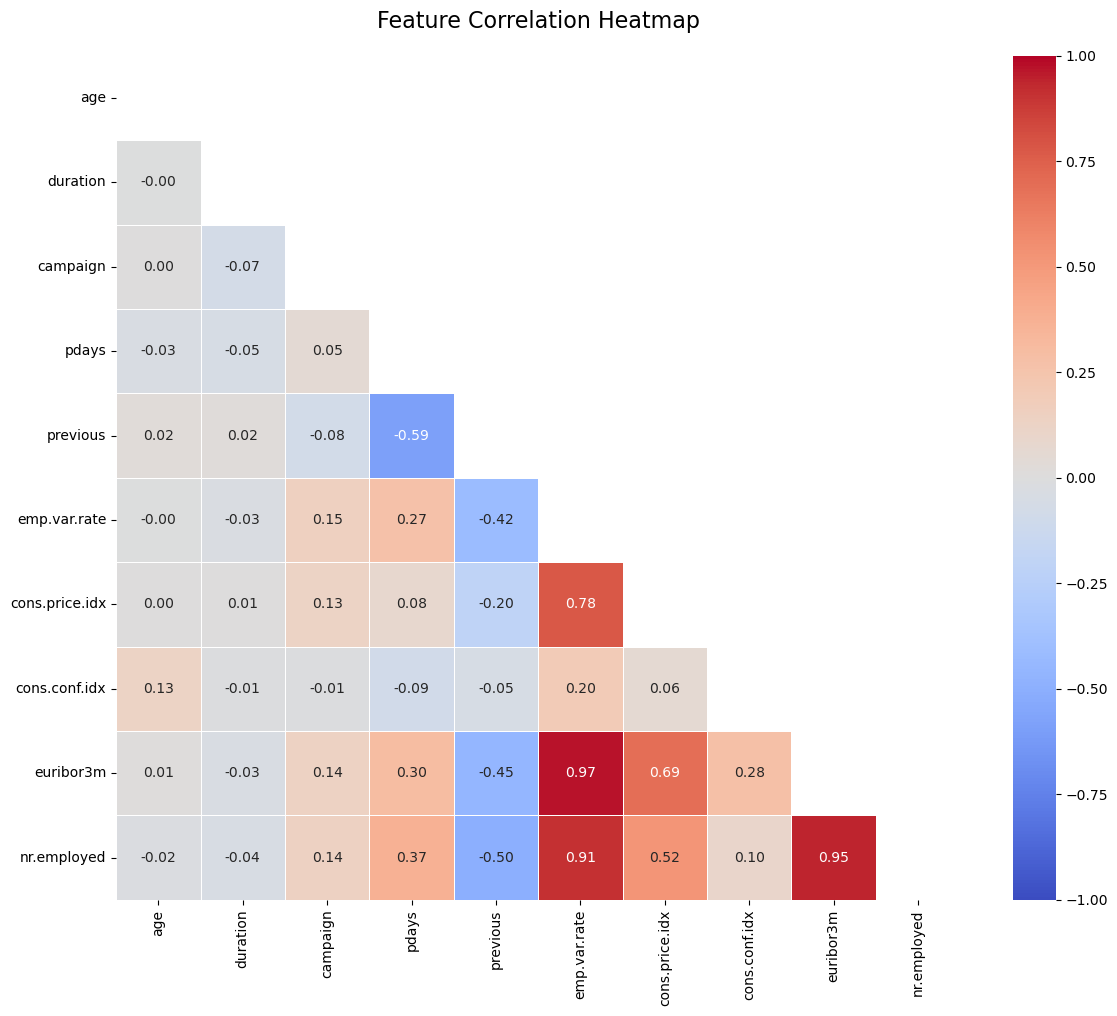

In [17]:

numerical_df = bank_data.select_dtypes(include=['float64', 'int64'])

corr_matrix = numerical_df.corr()
plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,              
    annot=True,             
    fmt=".2f",              
    cmap='coolwarm',        
    vmin=-1, vmax=1,        
    square=True,            
    linewidths=0.5          
)
plt.title('Feature Correlation Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


# Feature Engineering

## Feature selection and extraction

In [18]:
bank_data=bank_data.drop(columns=['euribor3m', 'emp.var.rate'])

**We are dropping this columns because there exists multicollinearity between them and nr.employed**

# Adding new column "is_new_client" to the dataset

In [19]:
bank_data['is_new_client'] = bank_data['pdays'].apply(lambda x: 1 if x == 999 else 0)

## dropping the columns ['duration',"pdays"] 

In [20]:
bank_data=bank_data.drop(columns=['duration',"pdays"])

**As mentioned in the description of the column "Duration", this should be removed to have a realistic predictive model. And we have created a relevant column "is_new_client" from pdays column. So, we can remove this pdays column.**

## feature transformation

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_score


In [22]:
CT=ColumnTransformer(transformers=[("ohe",OneHotEncoder(sparse_output=False),['job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week','poutcome']),
       ("std",StandardScaler(),["age", 'campaign',
       'previous',"nr.employed", 'cons.price.idx',
       'cons.conf.idx'])], remainder="passthrough")



The `ColumnTransformer` is a powerful tool that allows you to apply different mathematical transformations to different columns in your dataset simultaneously. Here is the exact breakdown of how your `CT` object is preparing the data:

### 1. The `OneHotEncoder` ("ohe")
* **Targeted Columns:** `'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome'`
* **What it does:** It takes categorical (text) variables and converts them into a machine-readable format. For example, instead of a single `marital` column with values like "married" or "single", it creates multiple binary columns (e.g., `marital_married`, `marital_single`) filled with `1`s and `0`s. 
* **Purpose:** Classification models cannot mathematically calculate patterns using text. One-Hot Encoding allows the algorithms to factor in these demographic and categorical details safely.
* **Special Parameter (`sparse_output=False`):** By default, OneHotEncoder creates a compressed "sparse matrix" to save memory. Setting this to `False` forces it to return a standard, dense NumPy array. This is often necessary when combining the output with other standard arrays, or when using models that do not support sparse matrices (like Gaussian Naive Bayes).

### 2. The `StandardScaler` ("std")
* **Targeted Columns:** `"age", 'campaign', 'previous', "nr.employed", 'cons.price.idx', 'cons.conf.idx'`
* **What it does:** It standardizes these continuous numerical columns so that they all have a mean (average) of `0` and a standard deviation of `1`. 
* **Purpose:** Your dataset contains features on vastly different scales. For instance, `age` is measured in decades, `campaign` (number of calls) is in single digits, and `cons.price.idx` (Consumer Price Index) is a highly specific decimal. Without scaling, a model might mistakenly assume that a feature with larger numbers is inherently more "important" than a feature with smaller numbers. Scaling puts all numerical data on an equal playing field.

### 3. The `remainder="passthrough"` Parameter
* **What it does:** This is a crucial setting for the `ColumnTransformer`. By default, if a ColumnTransformer processes specific columns, it automatically deletes (`drops`) any columns that were not explicitly mentioned in the lists above. 
* **Purpose:** Setting it to `"passthrough"` tells the code: *"If there are any other columns in my dataset that I didn't list in the OHE or StandardScaler lists, do not delete them! Just pass them straight through to the final dataset untouched."* This ensures you don't accidentally lose valuable data.

# Model Selection

In [23]:
X=bank_data.drop(columns=['y'])
Y= bank_data["y"]
Y=Y.map({'no':0,'yes':1})
X_train ,X_test , Y_train, Y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=123)

In [24]:
pipe_Gb= Pipeline(steps=[("ct",CT),("nb",GaussianNB())])
pipe_dtc= Pipeline(steps=[("ct",CT),("dtc",DecisionTreeClassifier())])

### Train-Test Split

* **`train_test_split(..., test_size=0.2, stratify=Y)`**
  * **What it does:** Splits your data so 80% is used to teach the model (`X_train`, `Y_train`) and 20% is hidden away to test it later (`X_test`, `Y_test`).
  * **Purpose:** To evaluate if the model actually learned the patterns or just memorized the answers.
  * **Special Parameter:** `stratify=Y` is absolutely crucial for your project. Because you have imbalanced data (more Flops than Hits, or vice versa), this ensures that both your 80% training set and 20% testing set contain the exact same ratio of Hits to Flops as the original dataset.

### The `Pipeline`

* **`Pipeline(steps=[...])`**
  * **What it does:** Chains your `ColumnTransformer` and your machine learning model together into a single object.
  * **Purpose:** It prevents "data leakage." When you call `.fit()` on the pipeline, it scales and encodes the training data, then trains the model. When you call `.predict()` on the test data, it automatically applies the exact same scaling and encoding rules before making predictions. It keeps your code exceptionally clean.



## Gaussian Naive Bayes Classifier

In [25]:

pipe_Gb.fit(X_train,Y_train)
Y_pred_Gb_train=pipe_Gb.predict(X_train)
Y_pred_Gb_test=pipe_Gb.predict(X_test)


In [26]:
print("Classification Report for Training set")
print(classification_report(Y_train,Y_pred_Gb_train))
print("Classification Report for Testing set")
print(classification_report(Y_test,Y_pred_Gb_test))
print("Confusion Matrix for Training set")
print(confusion_matrix(Y_train,Y_pred_Gb_train))
print("Confusion Matrix for Testing set")
print(confusion_matrix(Y_test,Y_pred_Gb_test))

Classification Report for Training set
              precision    recall  f1-score   support

           0       0.94      0.84      0.88     29229
           1       0.31      0.57      0.40      3711

    accuracy                           0.81     32940
   macro avg       0.62      0.70      0.64     32940
weighted avg       0.87      0.81      0.83     32940

Classification Report for Testing set
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      7308
           1       0.31      0.56      0.39       928

    accuracy                           0.81      8236
   macro avg       0.62      0.70      0.64      8236
weighted avg       0.87      0.81      0.83      8236

Confusion Matrix for Training set
[[24452  4777]
 [ 1610  2101]]
Confusion Matrix for Testing set
[[6132 1176]
 [ 411  517]]


In [27]:
print("Confusion Matrix for Training set")
print(confusion_matrix(Y_train,Y_pred_Gb_train))
print("Confusion Matrix for Testing set")
print(confusion_matrix(Y_test,Y_pred_Gb_test))

Confusion Matrix for Training set
[[24452  4777]
 [ 1610  2101]]
Confusion Matrix for Testing set
[[6132 1176]
 [ 411  517]]


## Decision Tree Classifier

In [28]:
pipe_dtc.fit(X_train,Y_train)
Y_pred_dtc_train=pipe_dtc.predict(X_train)
Y_pred_dtc_test=pipe_dtc.predict(X_test)

In [29]:
print("classification_report for Training set")
print(classification_report(Y_train,Y_pred_dtc_train))
print("classification_report for Testing set")
print(classification_report(Y_test,Y_pred_dtc_test))


classification_report for Training set
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     29229
           1       1.00      0.94      0.97      3711

    accuracy                           0.99     32940
   macro avg       1.00      0.97      0.98     32940
weighted avg       0.99      0.99      0.99     32940

classification_report for Testing set
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      7308
           1       0.32      0.33      0.33       928

    accuracy                           0.85      8236
   macro avg       0.62      0.62      0.62      8236
weighted avg       0.85      0.85      0.85      8236



In [30]:
print("Confusion Matrix for Training set")
print(confusion_matrix(Y_train,Y_pred_dtc_train))
print("Confusion Matrix for Testing set")
print(confusion_matrix(Y_test,Y_pred_dtc_test))

Confusion Matrix for Training set
[[29224     5]
 [  210  3501]]
Confusion Matrix for Testing set
[[6664  644]
 [ 618  310]]


# Baseline Models Performance Report: 

### 1. Evaluation Strategy
For this telemarketing campaign dataset, our goal is to accurately predict term deposit subscriptions (`y=1` for Yes, `y=0` for No) before placing a call. 

We evaluate the baseline models strictly against our business objectives:
* **Recall of Subscriptions (y=1):** Maximizing this ensures the bank catches as many potential subscribers as possible. 
* **Precision of Non-Subscriptions (y=0):** High precision here ensures that if the model tells us a client *won't* subscribe, we can confidently skip them without losing a potential sale.
* **Train vs. Test F1-Score:** Comparing these scores checks for overfitting.

---

### 2. Baseline Model Performance Comparison

*Note: The Decision Tree Classifier metrics reflect the distinct evaluation block provided in your baseline results.*

| Metric | Baseline Gaussian NB | Baseline Decision Tree |
| :--- | :---: | :---: |
| **Training F1-Score (Macro)** | 0.64 | 0.99 |
| **Testing F1-Score (Macro)** | 0.64 | 0.85 |
| **Recall of 'Yes' (y=1)** | **56%** |  34% |
| **Precision of 'No' (y=0)**| **94%** | 92%|
| **Overfitting Status** | None (Perfectly Stable) | OverFitting |



# Hyperparameter Tuning

In [31]:
from sklearn.model_selection import RandomizedSearchCV

## Gaussian Naive Bayes Classifier

In [32]:
pipe_Gb[1].get_params()

{'priors': None, 'var_smoothing': 1e-09}

In [33]:


param_dist_gnb = {
    "nb__priors": [None,[0.5, 0.5], [0.1, 0.9],[0.025, 0.975], [0.0625, 0.9375], [0.05, 0.95]],
    "nb__var_smoothing": np.logspace(-12, -6, 100)
}

# 2. Initialize the base Gaussian Naive Bayes model
gnb = pipe_Gb

# 3. Configure the RandomizedSearchCV
# We set scoring='recall' to strictly optimize for catching Class 1 (Flops)
random_search_gnb = RandomizedSearchCV(
    estimator=gnb,
    param_distributions=param_dist_gnb,
    n_iter=50,                  # Number of random combinations to try
    scoring='f1',           # Optimizing for your target minority class
    cv=5,                       # 5-fold cross-validation
    random_state=42,
    n_jobs=-1                   # Uses all available CPU cores
)

# 4. Fit the search to your training data
print("Hunting for the best GaussianNB parameters... please wait.")
random_search_gnb.fit(X_train, Y_train) 

# 5. Extract and print the best results
print("\n--- Gaussian Naive Bayes Tuning Results ---")
print(f"Best Recall Score achieved during CV: {random_search_gnb.best_score_:.4f}")
print("Best Hyperparameters found:")
for param, value in random_search_gnb.best_params_.items():
    print(f" - {param}: {value}")


best_gnb_model = random_search_gnb.best_estimator_

Hunting for the best GaussianNB parameters... please wait.

--- Gaussian Naive Bayes Tuning Results ---
Best Recall Score achieved during CV: 0.4062
Best Hyperparameters found:
 - nb__var_smoothing: 1.6297508346206436e-07
 - nb__priors: None


In [34]:
Y_pred_rnb_train=best_gnb_model.predict(X_train)
Y_pred_rnb_test=best_gnb_model.predict(X_test)
print("Classification Report for Training set")
print(classification_report(Y_train,Y_pred_rnb_train))
print("Classification Report for Testing set")
print(classification_report(Y_test,Y_pred_rnb_test))
print("Confusion Matrix for Training set")
print(confusion_matrix(Y_train,Y_pred_rnb_train))
print("Confusion Matrix for Testing set")
print(confusion_matrix(Y_test,Y_pred_rnb_test))

Classification Report for Training set
              precision    recall  f1-score   support

           0       0.93      0.88      0.91     29229
           1       0.35      0.51      0.41      3711

    accuracy                           0.84     32940
   macro avg       0.64      0.69      0.66     32940
weighted avg       0.87      0.84      0.85     32940

Classification Report for Testing set
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      7308
           1       0.35      0.49      0.41       928

    accuracy                           0.84      8236
   macro avg       0.64      0.69      0.66      8236
weighted avg       0.87      0.84      0.85      8236

Confusion Matrix for Training set
[[25674  3555]
 [ 1827  1884]]
Confusion Matrix for Testing set
[[6444  864]
 [ 472  456]]


## decision tree model

In [35]:
dt_model = pipe_dtc


dt_param_dist = {
    'dtc__criterion': ['gini', 'entropy'],
    'dtc__max_depth': [2,3,4,5,6,7,8,9,10,12,15,17,20,None],              
    'dtc__min_samples_split': np.arange(2, 20),      
    'dtc__min_samples_leaf': np.arange(1, 20), 
    'dtc__class_weight': [{0: 1, 1: 15} ,{0:1,1:20}, {0:1,1:25}, {0:1,1:30}]                   
}

dt_random_search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=dt_param_dist,
    n_iter=50,                         
    scoring='f1',   
    random_state=42,
    cv=5,
    n_jobs=-1
)

In [36]:
dt_random_search.fit(X_train,Y_train)

c:\Users\amanr\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('ct',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               OneHotEncoder(sparse_output=False),
                                                                               ['job',
                                                                                'marital',
                                                                                'education',
                                                                                'default',
                                                                                'housing',
                                                                                'loan',
                                                                                'contact',
                                                                                'month',
                                                                                'day_of_week',
                                                                                'poutcome']),
                                                                              ('std',
                                                                               StandardScaler(),
                                                                               ['age',
                                                                                'campaign',
                                                                                'previous',
                                                                                'nr.employed',
                                                                                'cons.price.idx',
                                                                                'cons.conf....
                   param_distributions={'dtc__class_weight': [{0: 1, 1: 15},
                                                              {0: 1, 1: 20},
                                                              {0: 1, 1: 25},
                                                              {0: 1, 1: 30}],
                                        'dtc__criterion': ['gini', 'entropy'],
                                        'dtc__max_depth': [2, 3, 4, 5, 6, 7, 8,
                                                           9, 10, 12, 15, 17,
                                                           20, None],
                                        'dtc__min_samples_leaf': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'dtc__min_samples_split': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19])},
                   random_state=42, scoring='f1')

In [37]:
dt_random_search.best_params_

{'dtc__min_samples_split': np.int64(16),
 'dtc__min_samples_leaf': np.int64(10),
 'dtc__max_depth': 4,
 'dtc__criterion': 'gini',
 'dtc__class_weight': {0: 1, 1: 15}}

In [38]:
Y_pred_rdtc_train=dt_random_search.predict(X_train)
Y_pred_rdtc_test=dt_random_search.predict(X_test)

In [39]:
print("Classification Report for Training set")
print(classification_report(Y_train,Y_pred_rdtc_train))
print("Classification Report for Testing set")
print(classification_report(Y_test,Y_pred_rdtc_test))
print("Confusion Matrix for Training set")
print(confusion_matrix(Y_train,Y_pred_rdtc_train))
print("Confusion Matrix for Testing set")
print(confusion_matrix(Y_test,Y_pred_rdtc_test))

Classification Report for Training set
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     29229
           1       0.25      0.71      0.37      3711

    accuracy                           0.73     32940
   macro avg       0.60      0.72      0.60     32940
weighted avg       0.87      0.73      0.77     32940

Classification Report for Testing set
              precision    recall  f1-score   support

           0       0.95      0.73      0.83      7308
           1       0.26      0.73      0.38       928

    accuracy                           0.73      8236
   macro avg       0.61      0.73      0.60      8236
weighted avg       0.88      0.73      0.78      8236

Confusion Matrix for Training set
[[21282  7947]
 [ 1062  2649]]
Confusion Matrix for Testing set
[[5360 1948]
 [ 254  674]]


# Bank Marketing Campaign: Predictive Model Evaluation

### 1. Business Objective & Evaluation Strategy
This project analyzes direct marketing campaigns (phone calls) of a Portuguese banking institution. The primary classification goal is to predict whether a client will subscribe to a term deposit (`y = 1` for Yes, `y = 0` for No). 

To maximize the efficiency and profitability of the telemarketing operations, we are evaluating our models based on specific, business-driven metrics:
* **Recall of Subscriptions (y=1):** The percentage of actual subscribers the model successfully identifies.  Maximizing this ensures the bank does not miss out on potential revenue opportunities by failing to call interested clients.
* **Precision of Non-Subscriptions (y=0):** When the model predicts a client will *not* subscribe, how often is it correct? High precision here means we can safely skip calling these individuals, saving telemarketers' time and reducing operational costs.
* **Train vs. Test F1-Score:** Comparing the F1-scores allows us to detect overfitting. If the training score is significantly higher than the testing score, the model is merely memorizing the data rather than learning actionable patterns.

---

### 2. Model Performance Comparison

| Metric | Gaussian Naive Bayes | Decision Tree Classifier |
| :--- | :---: | :---: |
| **Training F1-Score (Macro)** | 0.66 | 0.60 |
| **Testing F1-Score (Macro)** | 0.66 | 0.60 |
| **Recall of 'Yes' (y=1)** | 49% | **73%** |
| **Precision of 'No' (y=0)**| 93% | **95%** |
| **Overfitting Status** | None (Perfectly Stable) | None (Perfectly Stable) |

---

### 3. Gaussian Naive Bayes Analysis
The Gaussian Naive Bayes model demonstrated excellent stability.  The training and testing macro F1-scores are identical (0.66), indicating absolutely zero overfitting. 

However, looking at the targeted business metrics, it falls short of our operational goals:
* **Missed Opportunities:** The Recall for `y=1` is only 49% on the test set. This means the model fails to identify more than half of the customers who are actually willing to subscribe to a term deposit. Relying on this model would result in a massive amount of left-on-the-table revenue.
* **Operational Efficiency:** The Precision for `y=0` is solid at 93%, meaning it is generally safe to trust the model when it says a customer will decline. 

---

### 4. Decision Tree Classifier Analysis
The Decision Tree Classifier also proved to be highly robust and generalizable. Like the Naive Bayes model, its training and testing macro F1-scores remained perfectly consistent (0.60), confirming that there is no overfitting. 

Crucially, this model aligns much better with our strategic telemarketing goals:
* **Capturing Subscribers:** The Recall for `y=1` reached an impressive **73%** on the test set. It successfully identifies nearly three-quarters of all willing subscribers, vastly outperforming the Naive Bayes model and securing more conversions for the bank.
* **Optimizing Call Time:** The Precision for `y=0` improved to **95%**. This means that out of all the people the model flags as "Do Not Call" (because they won't subscribe), it is correct 95% of the time. This allows the call center to confidently filter out uninterested leads and focus their labor strictly on high-probability targets.

---

### Final Recommendation
The **Decision Tree Classifier is the definitive choice for this marketing campaign.** While both models successfully avoided overfitting, the Decision Tree is far superior at fulfilling the specific business objectives. By capturing 73% of potential subscribers while providing a 95% reliable filter against guaranteed rejections, this model will simultaneously increase term deposit conversions and reduce wasted telemarketing hours.

## Space And Time Profiling

### Decision Tree Classifier

In [40]:
import time
import tracemalloc

print("--- Training Decision Tree with Resource Tracking ---")

start_time = time.time()
tracemalloc.start()

pipe_dtc.fit(X_train, Y_train)


current_memory, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()
end_time = time.time()

print(f"Training Time: {end_time - start_time:.4f} seconds")
print(f"Peak Memory Usage: {peak_memory / 10**6:.4f} MB")

--- Training Decision Tree with Resource Tracking ---
Training Time: 0.8556 seconds
Peak Memory Usage: 31.8109 MB


### Gaussian Naive Bayes Classifier

In [41]:
import time
import tracemalloc

print("--- Training Bernoulli Naive Bayes with Resource Tracking ---")

start_time = time.time()
tracemalloc.start()

pipe_Gb.fit(X_train, Y_train)


current_memory, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()
end_time = time.time()

print(f"Training Time: {end_time - start_time:.4f} seconds")
print(f"Peak Memory Usage: {peak_memory / 10**6:.4f} MB")

--- Training Bernoulli Naive Bayes with Resource Tracking ---
Training Time: 0.2986 seconds
Peak Memory Usage: 44.1223 MB
